# Credit Risk Scoring Model  
### Financial Risk Analytics | Machine Learning | Decision-Oriented Modeling

This notebook builds an interpretable credit risk scoring model to estimate the probability of default for credit card clients.

**Business objective:** identify high-risk customers early, support credit decision-making, and reduce potential default-related losses.

**Workflow:** data loading → data quality checks → exploratory analysis → feature engineering → model training → SMOTE comparison → risk scoring → export for Power BI / business analysis.

## 1. Libraries and Global Settings

This section imports the libraries required for data analysis, visualization, machine learning, and model evaluation.

In [1]:
%matplotlib inline

import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix,
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 100)


## 2. Data Loading and Column Standardization

The dataset is loaded from the original CSV file.  
Column names are standardized to make the notebook easier to read and to align the analysis with credit risk terminology.

In [2]:
# ==============================
# DATA LOADING (CLEAN VERSION)
# ==============================

import pandas as pd

DATA_PATH = r"C:\Users\LENOVO\Desktop\Project 1\Dataset.csv"

credit_data = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully")
print("Shape:", credit_data.shape)

credit_data.head()

Dataset loaded successfully
Shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [3]:

# Standardize column names if the source file uses the original UCI/Kaggle naming convention.
rename_map = {
    "ID": "Customer_id",
    "LIMIT_BAL": "Credit_limit",
    "SEX": "Gender",
    "EDUCATION": "Education_level",
    "MARRIAGE": "Marital_status",
    "AGE": "Age",
    "PAY_0": "Repayment_status_month-1",
    "PAY_2": "Repayment_status_month-2",
    "PAY_3": "Repayment_status_month-3",
    "PAY_4": "Repayment_status_month-4",
    "PAY_5": "Repayment_status_month-5",
    "PAY_6": "Repayment_status_month-6",
    "BILL_AMT1": "Bill_amount_month-1",
    "BILL_AMT2": "Bill_amount_month-2",
    "BILL_AMT3": "Bill_amount_month-3",
    "BILL_AMT4": "Bill_amount_month-4",
    "BILL_AMT5": "Bill_amount_month-5",
    "BILL_AMT6": "Bill_amount_month-6",
    "PAY_AMT1": "Payment_amount_month-1",
    "PAY_AMT2": "Payment_amount_month-2",
    "PAY_AMT3": "Payment_amount_month-3",
    "PAY_AMT4": "Payment_amount_month-4",
    "PAY_AMT5": "Payment_amount_month-5",
    "PAY_AMT6": "Payment_amount_month-6",
    "default.payment.next.month": "payment_default_next_month",
}

credit_data.columns = credit_data.columns.str.strip()
credit_data.rename(columns={k: v for k, v in rename_map.items() if k in credit_data.columns}, inplace=True)

# Clean numeric columns when values are stored as text with commas.
for col in credit_data.columns:
    if credit_data[col].dtype == "object":
        cleaned_col = credit_data[col].astype(str).str.replace(",", ".", regex=False)
        credit_data[col] = pd.to_numeric(cleaned_col, errors="ignore")

print(f"Dataset loaded successfully from: {DATA_PATH}")
print(f"Dataset shape: {credit_data.shape}")
display(credit_data.head())


Dataset loaded successfully from: C:\Users\LENOVO\Desktop\Project 1\Dataset.csv
Dataset shape: (30000, 25)


,Customer_id,Credit_limit,Gender,Education_level,Marital_status,Age,Repayment_status_month-1,Repayment_status_month-2,Repayment_status_month-3,Repayment_status_month-4,Repayment_status_month-5,Repayment_status_month-6,Bill_amount_month-1,Bill_amount_month-2,Bill_amount_month-3,Bill_amount_month-4,Bill_amount_month-5,Bill_amount_month-6,Payment_amount_month-1,Payment_amount_month-2,Payment_amount_month-3,Payment_amount_month-4,Payment_amount_month-5,Payment_amount_month-6,payment_default_next_month
0,1,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## 3. Dataset Overview and Data Quality Checks

Before modeling, the dataset structure is reviewed to confirm the number of observations, data types, missing values, and duplicates.

**Business relevance:** data quality is critical in credit risk modeling because inconsistent or missing values can distort risk estimation.

In [4]:
# Dataset dimensions
credit_data.shape

(30000, 25)

In [5]:
# Dataset structure and data types
credit_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Customer_id                 30000 non-null  int64  
 1   Credit_limit                30000 non-null  float64
 2   Gender                      30000 non-null  int64  
 3   Education_level             30000 non-null  int64  
 4   Marital_status              30000 non-null  int64  
 5   Age                         30000 non-null  int64  
 6   Repayment_status_month-1    30000 non-null  int64  
 7   Repayment_status_month-2    30000 non-null  int64  
 8   Repayment_status_month-3    30000 non-null  int64  
 9   Repayment_status_month-4    30000 non-null  int64  
 10  Repayment_status_month-5    30000 non-null  int64  
 11  Repayment_status_month-6    30000 non-null  int64  
 12  Bill_amount_month-1         30000 non-null  float64
 13  Bill_amount_month-2         300

In [6]:
# Missing values check
missing_values = credit_data.isnull().sum()
display(missing_values[missing_values > 0])

# Duplicate rows check
duplicate_rows = credit_data.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

Series([], dtype: int64)

Number of duplicate rows: 0


## 4. Target Distribution and Categorical Risk Analysis

This section explores the default target and key categorical variables.

**Business relevance:** credit risk models usually face class imbalance because default events are less frequent than non-default events.

In [7]:
target = 'payment_default_next_month'



print("Gender:\n", credit_data['Gender'].value_counts())
print("\nEducation Level:\n", credit_data['Education_level'].value_counts())
print("\nMarital Status:\n", credit_data['Marital_status'].value_counts())

Gender:
 Gender
2    18112
1    11888
Name: count, dtype: int64

Education Level:
 Education_level
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64

Marital Status:
 Marital_status
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64


### Categorical variables analysis

**Gender**

The portfolio is composed of 18,112 women and 11,888 men, representing approximately 60% women and 40% men.

This distribution shows a higher representation of female customers in the dataset.

**Education level**

Most customers have a university or graduate school education:

- Level 2: 14,030 customers (~42%)
- Level 1: 10,585 customers (~32%)

Higher/other education categories (3, 4, 5, 6) represent a smaller share of the portfolio, with only 51 customers in level 6 and 14 customers in level 0.

This distribution suggests that most customers have a medium to high education level, which can influence risk behavior and the understanding of financial products.

**Marital status**

Most customers are single or married, with only a small share classified as “Others” or unknown.

From a risk management perspective, categorical variables are useful for segmentation, but they should be interpreted carefully and combined with stronger financial and behavioral indicators.

In [8]:
gender_map = {1: "Male", 2: "Female"}
education_map = {
    1: "Graduate School",
    2: "University",
    3: "High School",
    4: "Others"
}
marital_map = {
    1: "Married",
    2: "Single",
    3: "Others"
}

credit_data['Gender_label'] = credit_data['Gender'].map(gender_map)
credit_data['Education_label'] = credit_data['Education_level'].map(education_map)
credit_data['Marital_label'] = credit_data['Marital_status'].map(marital_map)

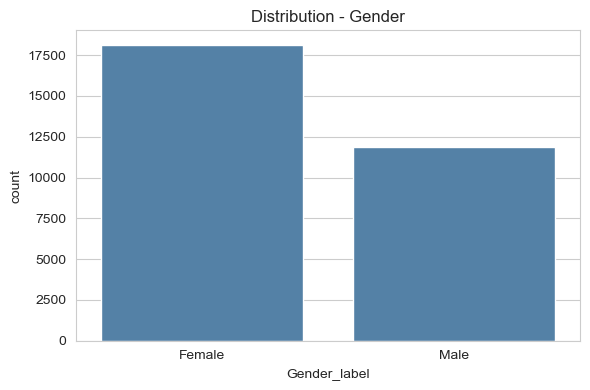

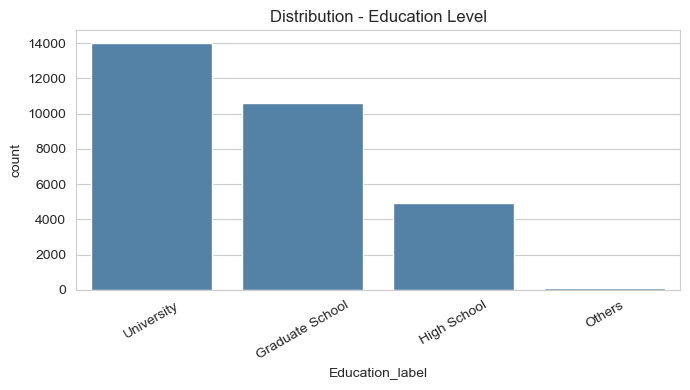

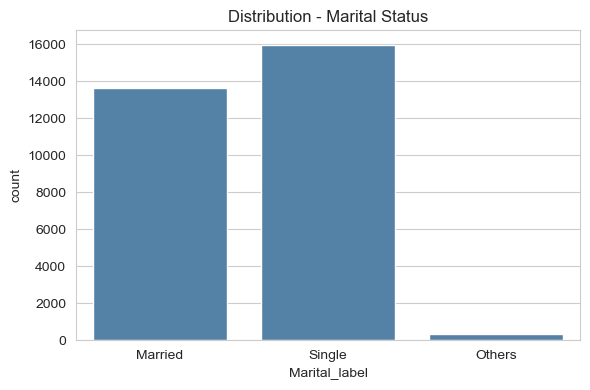

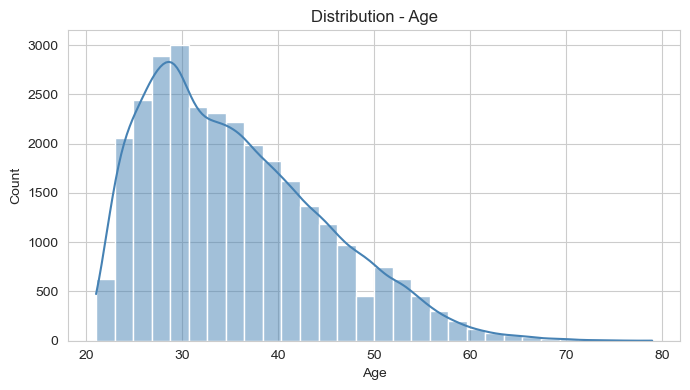

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender_label', data=credit_data, color='steelblue')
plt.title("Distribution - Gender")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
sns.countplot(x='Education_label', data=credit_data, color='steelblue')
plt.title("Distribution - Education Level")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x='Marital_label', data=credit_data, color='steelblue')
plt.title("Distribution - Marital Status")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
sns.histplot(credit_data['Age'], bins=30, kde=True, color='steelblue')
plt.title("Distribution - Age")
plt.tight_layout()
plt.show()

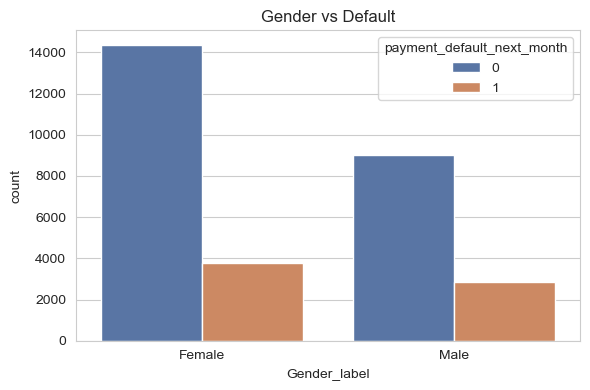

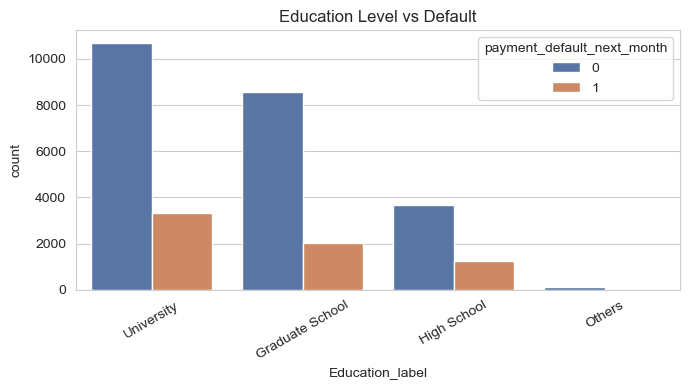

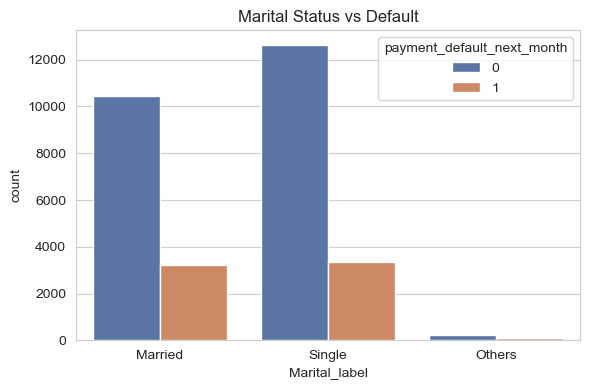

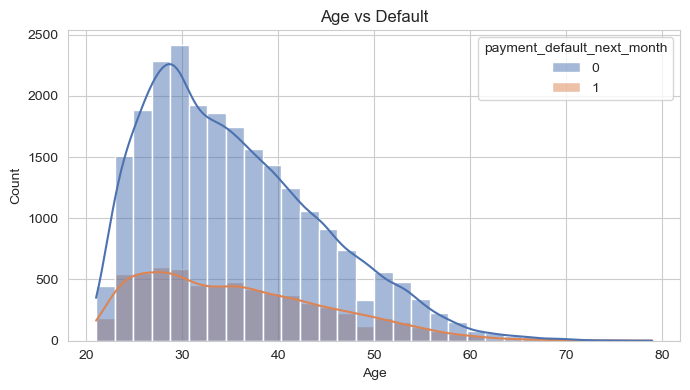

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender_label', hue=target, data=credit_data, palette='deep')
plt.title("Gender vs Default")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
sns.countplot(x='Education_label', hue=target, data=credit_data, palette='deep')
plt.title("Education Level vs Default")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x='Marital_label', hue=target, data=credit_data, palette='deep')
plt.title("Marital Status vs Default")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
sns.histplot(data=credit_data, x='Age', hue=target, bins=30, kde=True, palette='deep')
plt.title("Age vs Default")
plt.tight_layout()
plt.show()

In [11]:
print("\nDefault Rate by Gender:")
print(credit_data.groupby('Gender_label')[target].mean())

print("\nDefault Rate by Education:")
print(credit_data.groupby('Education_label')[target].mean())

print("\nDefault Rate by Marital Status:")
print(credit_data.groupby('Marital_label')[target].mean())


Default Rate by Gender:
Gender_label
Female    0.207763
Male      0.241672
Name: payment_default_next_month, dtype: float64

Default Rate by Education:
Education_label
Graduate School    0.192348
High School        0.251576
Others             0.056911
University         0.237349
Name: payment_default_next_month, dtype: float64

Default Rate by Marital Status:
Marital_label
Married    0.234717
Others     0.260062
Single     0.209283
Name: payment_default_next_month, dtype: float64


### Default rate by categorical segment

**Default rate by gender**

- Female: 20.8%
- Male: 24.2%

Male customers show a slightly higher default rate than female customers, which may indicate a moderately higher risk in this segment.

**Default rate by education level**

- Graduate School: 19.2%
- University: 23.7%
- High School: 25.2%
- Others: 5.7%

Customers with a higher education level tend to show a lower default rate, while customers with only high school education show a higher risk profile.

The “Others” group has a very small sample size, so its lower default rate should be interpreted cautiously.

**Default rate by marital status**

- Married: 23.5%
- Single: 20.9%
- Others: 26.0%

Married customers show a slightly higher default rate than single customers. However, the difference remains moderate and should not be used alone for credit decision-making.


Default Rate by Age Group:
Age_Group
20-30    0.224371
30-40    0.204331
40-50    0.232973
50-60    0.252379
60+      0.268382
Name: payment_default_next_month, dtype: float64


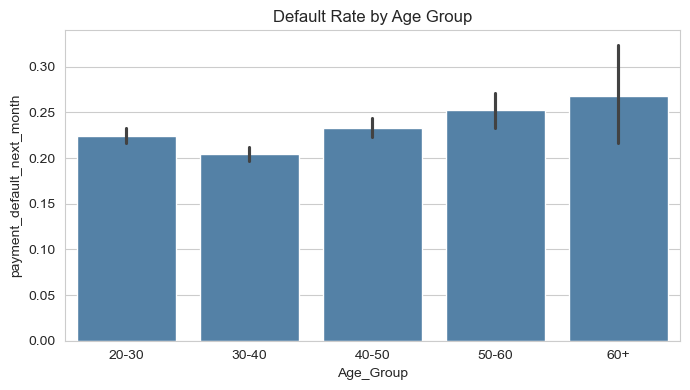

In [12]:
credit_data['Age_Group'] = pd.cut(
    credit_data['Age'],
    bins=[20, 30, 40, 50, 60, 80],
    labels=["20-30", "30-40", "40-50", "50-60", "60+"]
)

print("\nDefault Rate by Age Group:")
print(credit_data.groupby('Age_Group', observed=False)[target].mean())

plt.figure(figsize=(7,4))
sns.barplot(x='Age_Group', y=target, data=credit_data, color='steelblue')
plt.title("Default Rate by Age Group")
plt.tight_layout()
plt.show()

### Default rate by age group

- 20–30: 22.4%
- 30–40: 20.4%
- 40–50: 23.3%
- 50–60: 25.2%
- 60+: 26.8%

**Business interpretation**

Default rates tend to increase with age, reaching 26.8% for customers aged 60 and above.

The 30–40 age group shows the lowest risk level, while customers above 50 show higher risk. This may be linked to repayment capacity, income stability, or higher financial commitments.

These trends can help prioritize monitoring and preventive actions for the highest-risk segments.

## 5. Numerical Analysis and Outlier Review

Financial variables such as bill amounts, payment amounts, and credit limits often contain extreme values.  
These values are not automatically removed because they may represent real customer exposure and repayment behavior.

In [13]:
# ============================================================
# Statistical Summary
# ============================================================
# Basic statistics for numerical variables

numeric_cols = [
    'Credit_limit', 'Age',
    'Repayment_status_month-1','Repayment_status_month-2','Repayment_status_month-3',
    'Repayment_status_month-4','Repayment_status_month-5','Repayment_status_month-6',
    'Bill_amount_month-1','Bill_amount_month-2','Bill_amount_month-3',
    'Bill_amount_month-4','Bill_amount_month-5','Bill_amount_month-6',
    'Payment_amount_month-1','Payment_amount_month-2','Payment_amount_month-3',
    'Payment_amount_month-4','Payment_amount_month-5','Payment_amount_month-6'
]


# Statistical summary to identify outliers
print("Statistical summary of raw numerical columns:")
display(credit_data[numeric_cols].describe())

Statistical summary of raw numerical columns:


,Credit_limit,Age,Repayment_status_month-1,Repayment_status_month-2,Repayment_status_month-3,Repayment_status_month-4,Repayment_status_month-5,Repayment_status_month-6,Bill_amount_month-1,Bill_amount_month-2,Bill_amount_month-3,Bill_amount_month-4,Bill_amount_month-5,Bill_amount_month-6,Payment_amount_month-1,Payment_amount_month-2,Payment_amount_month-3,Payment_amount_month-4,Payment_amount_month-5,Payment_amount_month-6
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000
mean,167484.322667,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,-0.291100,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567
std,129747.661567,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,1.149988,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775
min,10000.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000
25%,50000.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000
50%,140000.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000
75%,240000.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000
max,1000000.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000


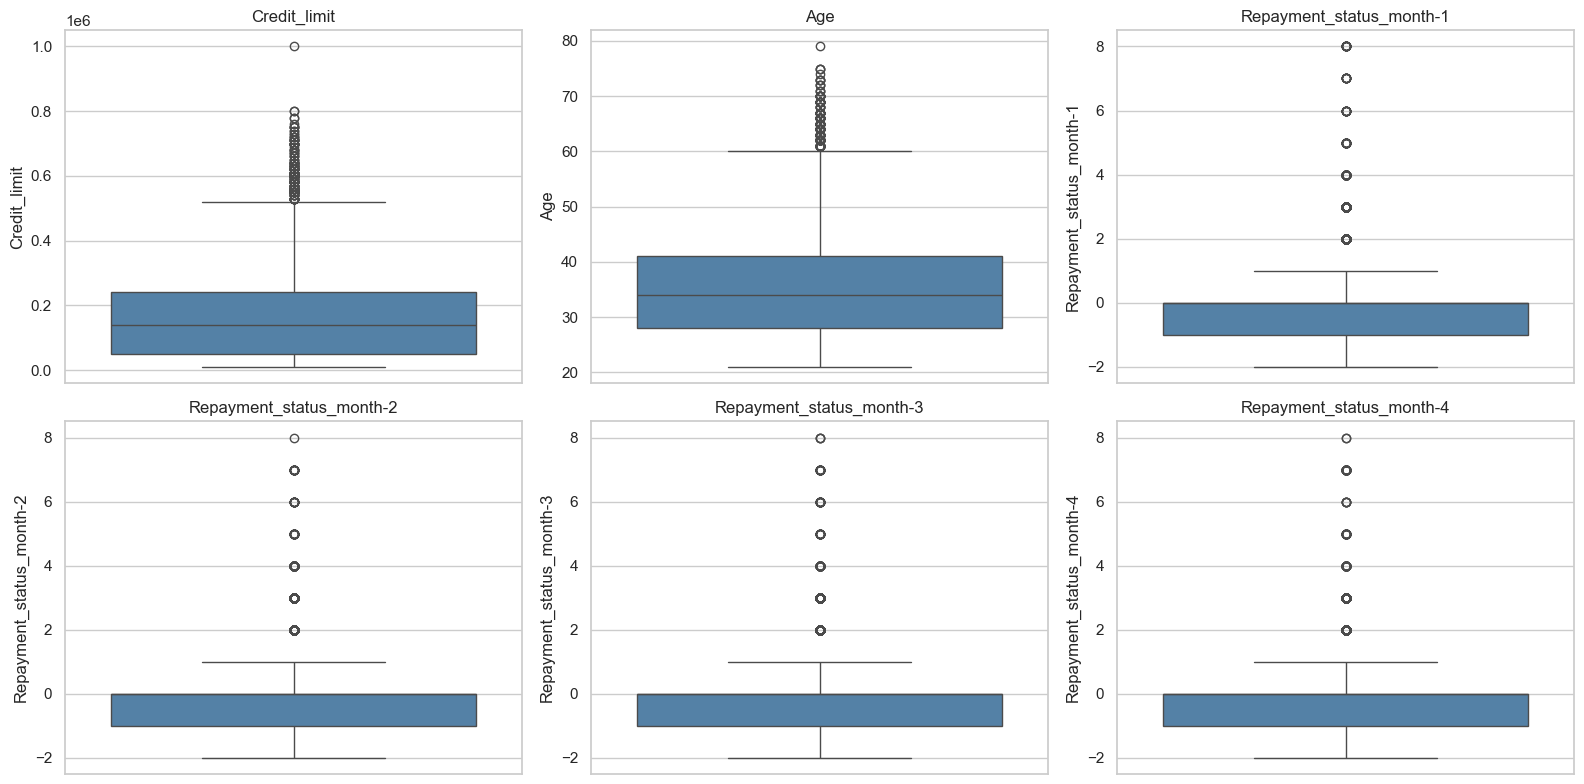

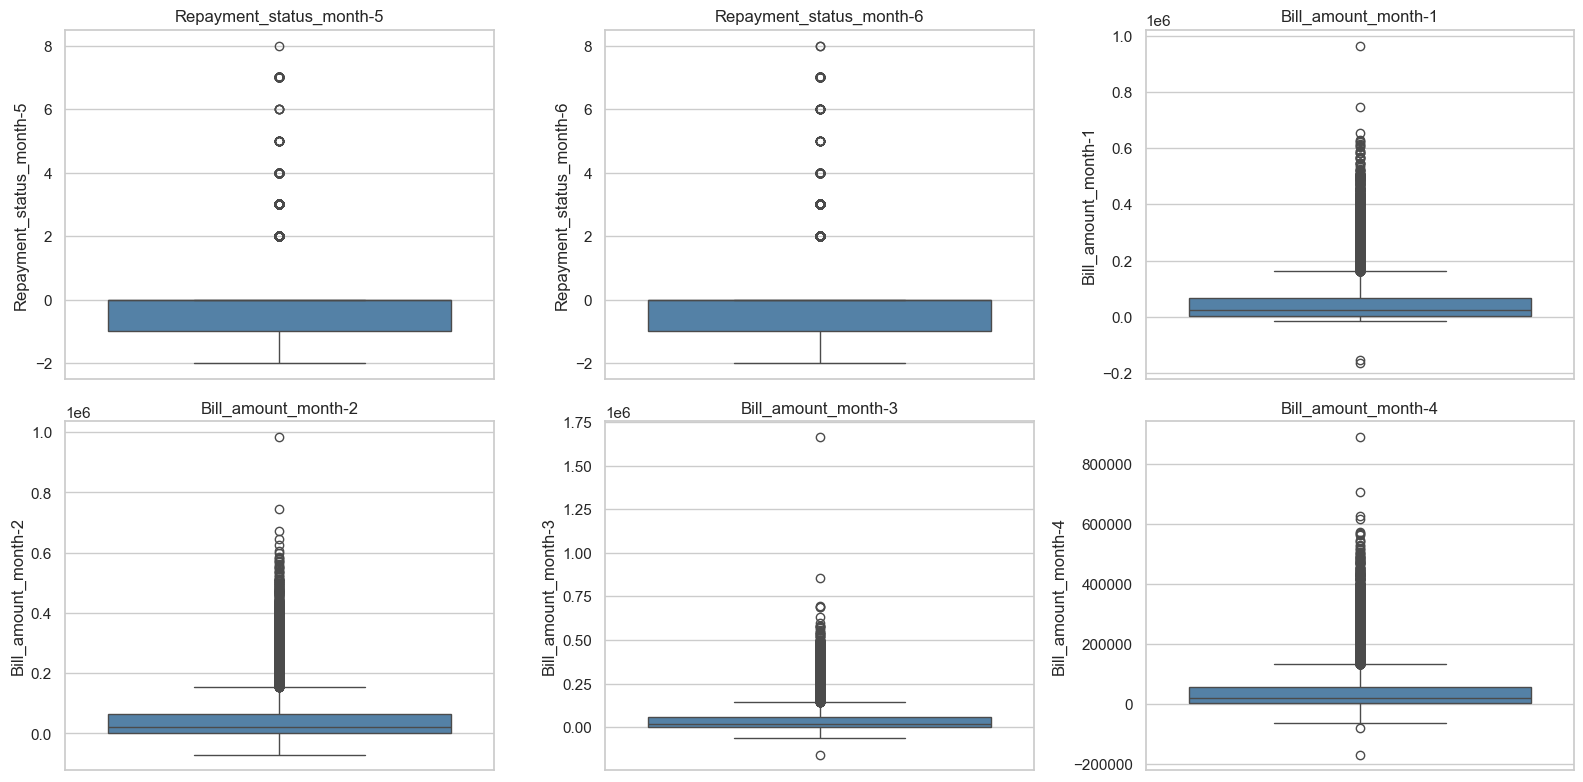

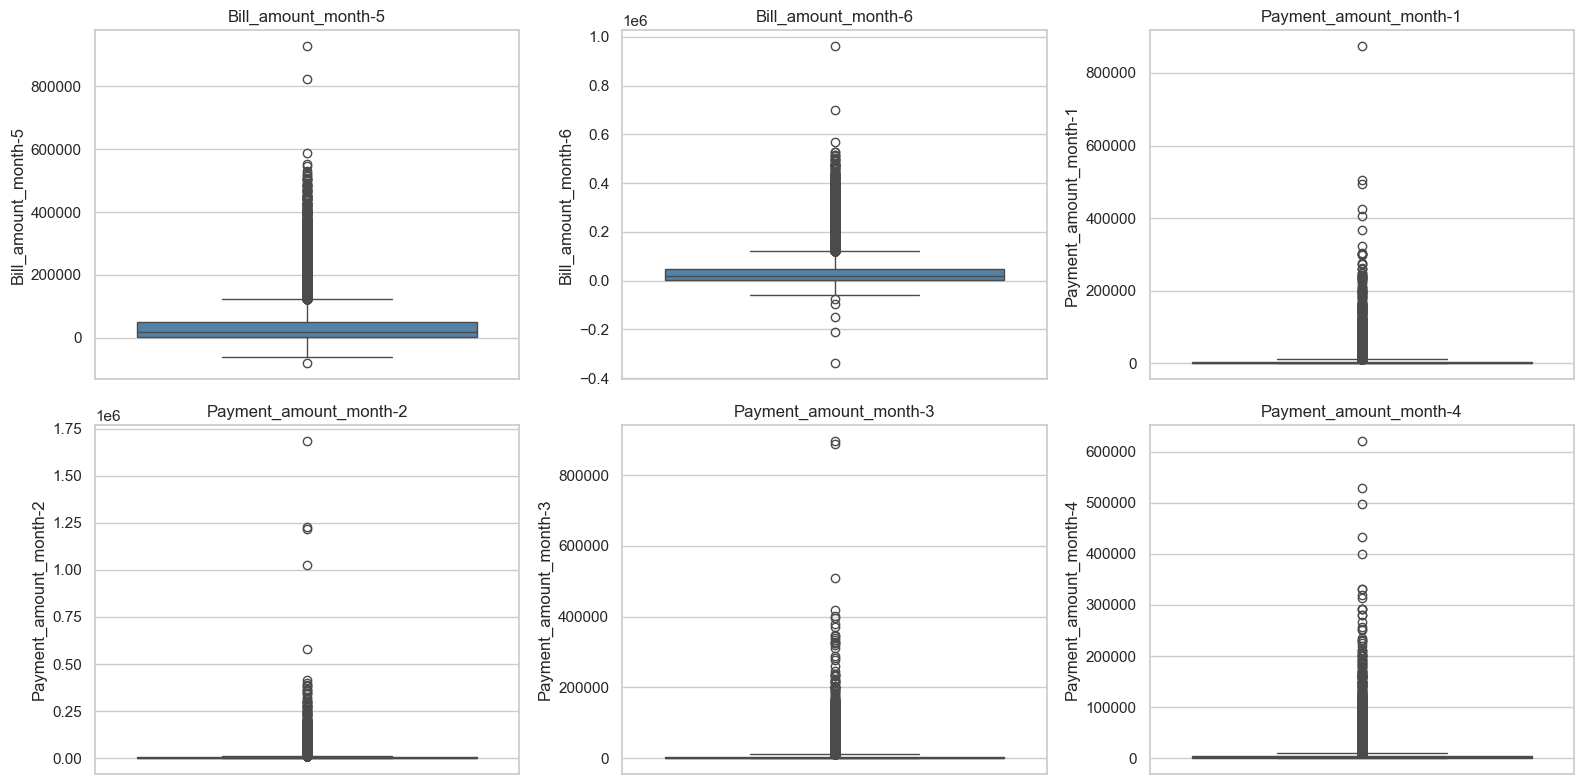

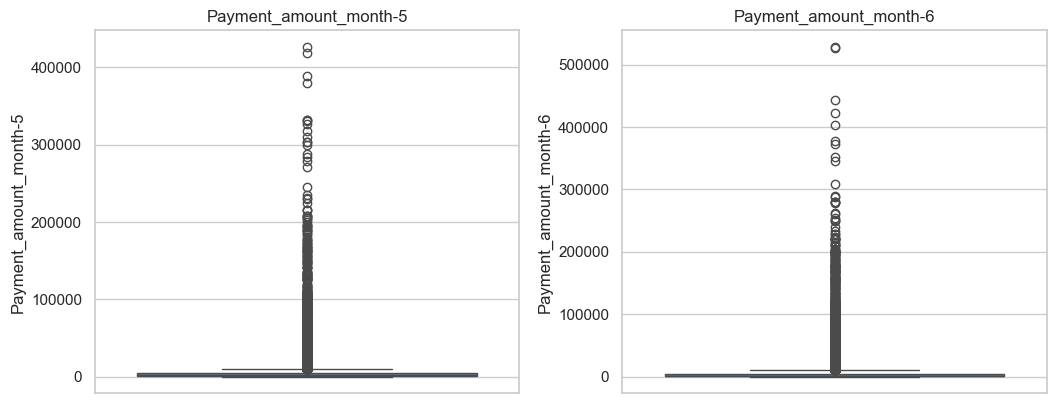

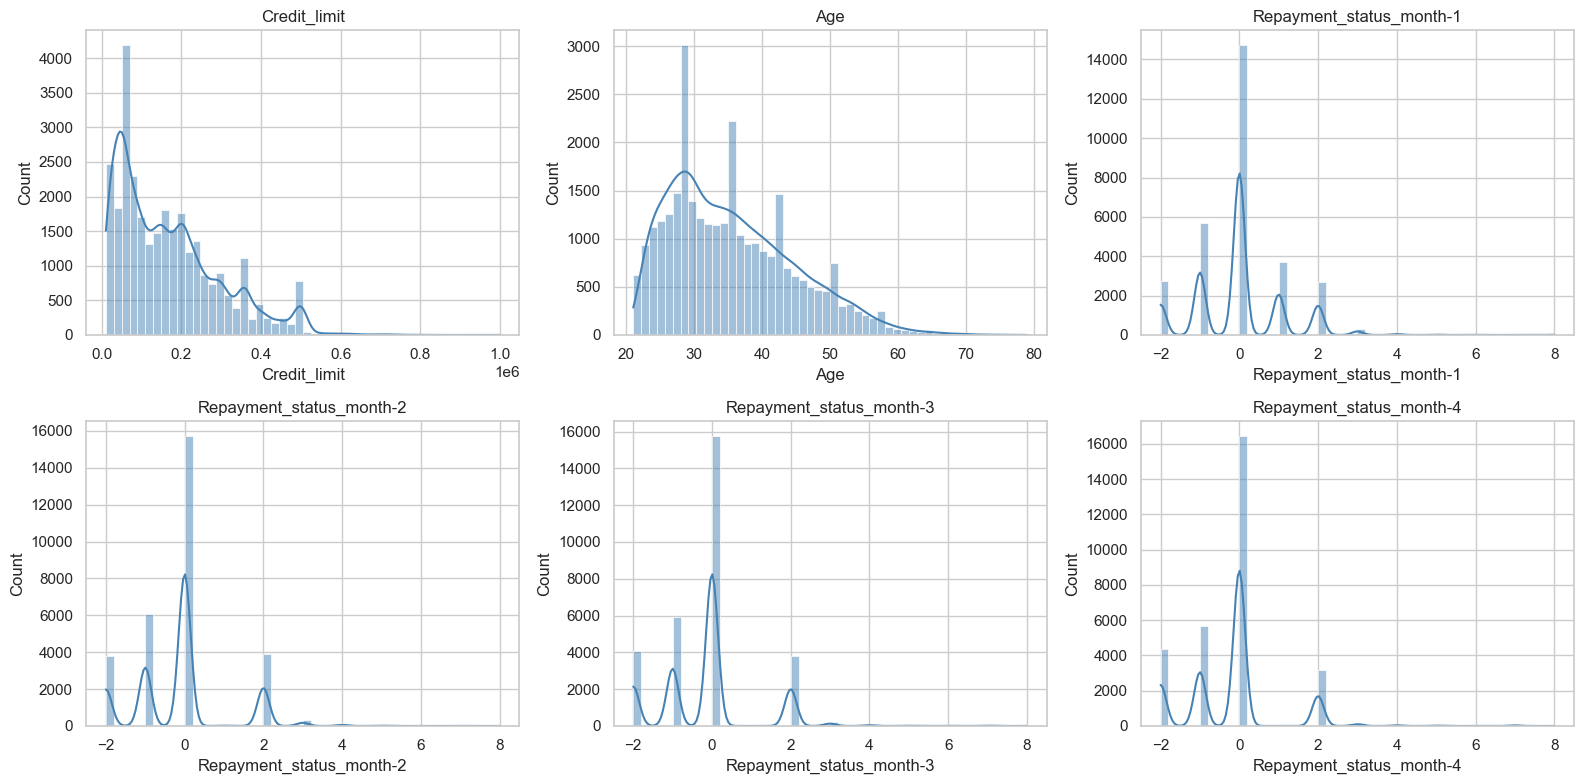

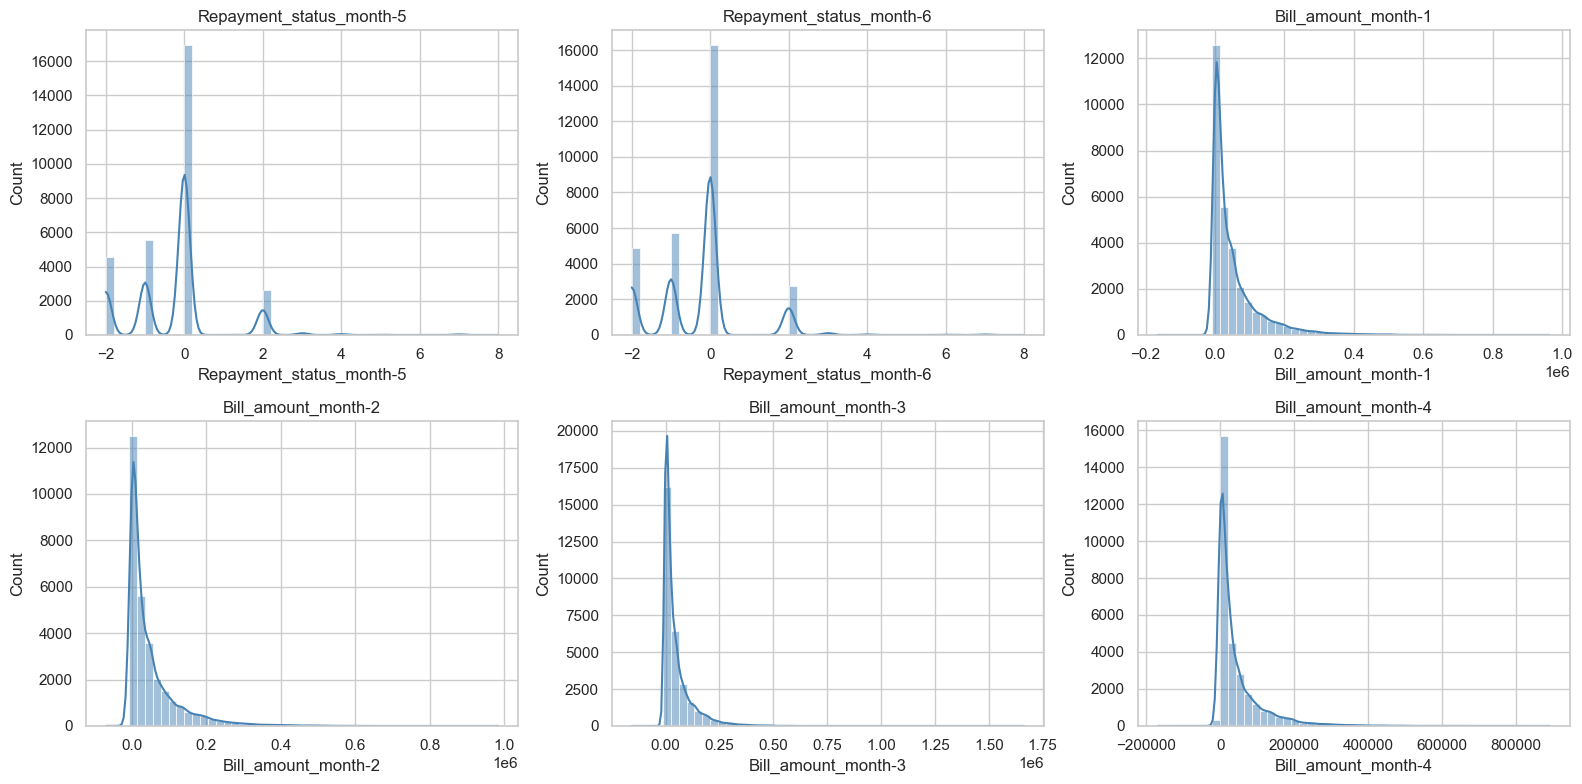

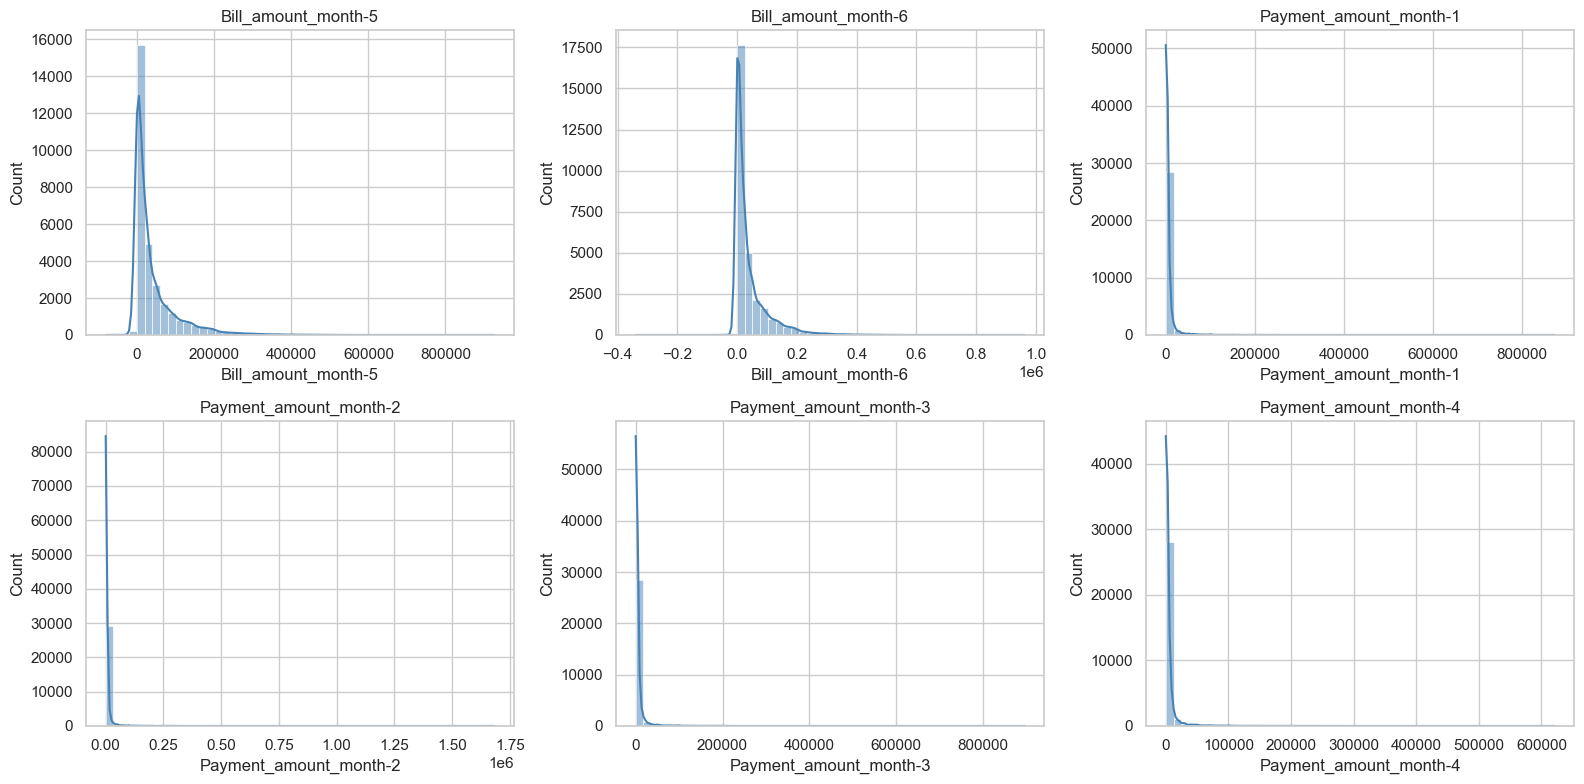

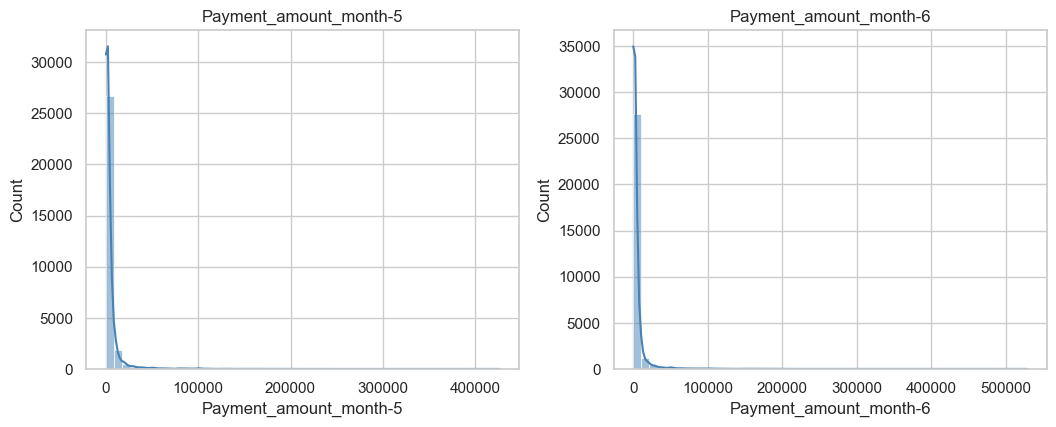

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

cols_per_fig = 6  

for start in range(0, len(numeric_cols), cols_per_fig):
    end = start + cols_per_fig
    subset_cols = numeric_cols[start:end]

    plt.figure(figsize=(16, 8))  
    for i, col in enumerate(subset_cols, 1):
        plt.subplot(2, 3, i)  
        sns.boxplot(y=credit_data[col].dropna(), color='steelblue')
        plt.title(col, fontsize=12)
    plt.tight_layout()
    plt.show()

for start in range(0, len(numeric_cols), cols_per_fig):
    end = start + cols_per_fig
    subset_cols = numeric_cols[start:end]

    plt.figure(figsize=(16, 8))  
    for i, col in enumerate(subset_cols, 1):
        plt.subplot(2, 3, i)
        sns.histplot(credit_data[col].dropna(), bins=50, kde=True, color='steelblue')
        plt.title(col, fontsize=12)
    plt.tight_layout()
    plt.show()

### Outlier detection

Outliers are present across many financial variables, especially payment amounts, bill amounts and age.

This is expected in financial datasets because customer exposure, credit limits and transaction amounts can vary significantly across the portfolio.

### Outlier treatment decision

The IQR method is used only to count and understand the volume of outliers.

Outliers are not removed because the high dispersion is economically meaningful: customers have different credit limits, billing patterns and payment behaviors.

Removing too many observations would distort the portfolio structure and weaken the model’s business relevance.

In [15]:
def count_outliers(df, cols):
    outlier_counts = {}
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_counts[col] = len(outliers)
    return pd.DataFrame.from_dict(outlier_counts, orient='index', columns=['Outlier_count'])

numeric_cols = [
    'Credit_limit', 'Age',
    'Repayment_status_month-1','Repayment_status_month-2','Repayment_status_month-3',
    'Repayment_status_month-4','Repayment_status_month-5','Repayment_status_month-6',
    'Bill_amount_month-1','Bill_amount_month-2','Bill_amount_month-3',
    'Bill_amount_month-4','Bill_amount_month-5','Bill_amount_month-6',
    'Payment_amount_month-1','Payment_amount_month-2','Payment_amount_month-3',
    'Payment_amount_month-4','Payment_amount_month-5','Payment_amount_month-6'
]
outliers_table = count_outliers(credit_data, numeric_cols)
display(outliers_table.sort_values(by='Outlier_count', ascending=False))

,Outlier_count
Repayment_status_month-2,4410
Repayment_status_month-3,4209
Repayment_status_month-4,3508
Repayment_status_month-1,3130
Repayment_status_month-6,3079
Payment_amount_month-4,2994
Repayment_status_month-5,2968
Payment_amount_month-6,2958
Payment_amount_month-5,2945
Payment_amount_month-1,2745


### Percentile capping

Percentile capping is used as a more appropriate approach for this type of financial data.

Instead of removing extreme observations, values are capped at the 1st and 99th percentiles to reduce the impact of extreme values while preserving portfolio information.

In [16]:
# Percentile capping to reduce the influence of extreme values while preserving information.
# --- Function to apply percentile capping (1st and 99th percentiles) ---
def percentile_capping(df, cols):
    df_capped = df.copy()
    for col in cols:
        lower = df_capped[col].quantile(0.01)
        upper = df_capped[col].quantile(0.99)
        df_capped[col] = np.where(df_capped[col] < lower, lower, df_capped[col])
        df_capped[col] = np.where(df_capped[col] > upper, upper, df_capped[col])
    return df_capped

# --- Apply capping ---
credit_data_capped = percentile_capping(credit_data, numeric_cols)

repay_cols = [f'Repayment_status_month-{i}' for i in range(1, 7)]
bill_cols  = [f'Bill_amount_month-{i}' for i in range(1, 7)]
pay_cols   = [f'Payment_amount_month-{i}' for i in range(1, 7)]

# Quick validation after capping
display(credit_data_capped[numeric_cols].describe())

,Credit_limit,Age,Repayment_status_month-1,Repayment_status_month-2,Repayment_status_month-3,Repayment_status_month-4,Repayment_status_month-5,Repayment_status_month-6,Bill_amount_month-1,Bill_amount_month-2,Bill_amount_month-3,Bill_amount_month-4,Bill_amount_month-5,Bill_amount_month-6,Payment_amount_month-1,Payment_amount_month-2,Payment_amount_month-3,Payment_amount_month-4,Payment_amount_month-5,Payment_amount_month-6
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,166808.656000,35.447167,-0.026433,-0.142767,-0.176533,-0.233867,-0.278433,-0.301967,50423.283733,48380.464567,46174.230967,42510.317067,39581.215733,38200.797233,5029.561633,5088.719567,4555.447400,4246.447100,4200.113300,4553.894133
std,127584.472995,9.090242,1.083593,1.164057,1.156639,1.113829,1.079821,1.102523,69304.686094,66803.121894,64352.130474,60049.132356,56585.314536,55409.361537,9430.870444,10341.622162,9560.267421,9272.507135,9063.279373,11039.458690
min,10000.000000,22.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-81.000000,-200.000000,-200.000000,-212.020000,-232.010000,-331.030000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,3558.750000,2984.750000,2666.250000,2326.750000,1763.000000,1256.000000,1000.000000,833.000000,390.000000,296.000000,252.500000,117.750000
50%,140000.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22381.500000,21200.000000,20088.500000,19052.000000,18104.500000,17071.000000,2100.000000,2009.000000,1800.000000,1500.000000,1500.000000,1500.000000
75%,240000.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67091.000000,64006.250000,60164.750000,54506.000000,50190.500000,49198.250000,5006.000000,5000.000000,4505.000000,4013.250000,4031.500000,4000.000000
max,500000.000000,60.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,350110.680000,337495.280000,325030.390000,304997.270000,285868.330000,279505.060000,66522.180000,76651.020000,70000.000000,67054.440000,65607.560000,82619.050000


In [17]:
# Quick preview after capping
credit_data_capped.head()

,Customer_id,Credit_limit,Gender,Education_level,Marital_status,Age,Repayment_status_month-1,Repayment_status_month-2,Repayment_status_month-3,Repayment_status_month-4,Repayment_status_month-5,Repayment_status_month-6,Bill_amount_month-1,Bill_amount_month-2,Bill_amount_month-3,Bill_amount_month-4,Bill_amount_month-5,Bill_amount_month-6,Payment_amount_month-1,Payment_amount_month-2,Payment_amount_month-3,Payment_amount_month-4,Payment_amount_month-5,Payment_amount_month-6,payment_default_next_month,Gender_label,Education_label,Marital_label,Age_Group
0,1,20000.0,2,2,1,24.0,2.0,2.0,-1.0,-1.0,-2.0,-2.0,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1,Female,University,Married,20-30
1,2,120000.0,2,2,2,26.0,-1.0,2.0,0.0,0.0,0.0,2.0,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1,Female,University,Single,20-30
2,3,90000.0,2,2,2,34.0,0.0,0.0,0.0,0.0,0.0,0.0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0,Female,University,Single,30-40
3,4,50000.0,2,2,1,37.0,0.0,0.0,0.0,0.0,0.0,0.0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0,Female,University,Married,30-40
4,5,50000.0,1,2,1,57.0,-1.0,0.0,-1.0,0.0,0.0,0.0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0,Male,University,Married,50-60


## 6. Feature Engineering — Financial Behavior Indicators

New variables are created to capture repayment behavior, financial exposure, repayment capacity, and payment consistency.

These engineered features are more useful for risk modeling than raw variables alone because they translate financial behavior into measurable risk signals.

In [18]:
# Repayment behavior indicators
credit_data_capped['Average_delay'] = credit_data_capped[repay_cols].mean(axis=1)
credit_data_capped['Max_delay'] = credit_data_capped[repay_cols].max(axis=1)
credit_data_capped['Num_late_payments'] = (credit_data_capped[repay_cols] > 0).sum(axis=1)
credit_data_capped['Std_delay'] = credit_data_capped[repay_cols].std(axis=1)

# Financial exposure and repayment capacity
credit_data_capped['Total_bill'] = credit_data_capped[bill_cols].sum(axis=1)
credit_data_capped['Total_payment'] = credit_data_capped[pay_cols].sum(axis=1)

# Payment-to-bill ratio: repayment effort compared to total outstanding balance
credit_data_capped['Payment_to_Bill_Ratio'] = credit_data_capped['Total_payment'] / np.where(
    credit_data_capped['Total_bill'] == 0, 1, credit_data_capped['Total_bill']
)
credit_data_capped['Payment_to_Bill_Ratio'] = credit_data_capped['Payment_to_Bill_Ratio'].clip(0, 5)

# Monthly payment-to-bill ratios
for i in range(1, 7):
    bill_col = f'Bill_amount_month-{i}'
    pay_col = f'Payment_amount_month-{i}'
    ratio_col = f'PBR_month{i}'

    credit_data_capped[ratio_col] = credit_data_capped[pay_col] / np.where(
        credit_data_capped[bill_col] == 0, 1, credit_data_capped[bill_col]
    )

credit_data_capped['Avg_Payment_to_Bill'] = credit_data_capped[
    ['PBR_month1','PBR_month2','PBR_month3','PBR_month4','PBR_month5','PBR_month6']
].mean(axis=1)

credit_data_capped['Std_PBR'] = credit_data_capped[
    ['PBR_month1','PBR_month2','PBR_month3','PBR_month4','PBR_month5','PBR_month6']
].std(axis=1)

# Credit utilization and trend indicators
credit_data_capped['Credit_utilization'] = credit_data_capped['Total_bill'] / np.where(
    credit_data_capped['Credit_limit'] == 0, 1, credit_data_capped['Credit_limit']
)
credit_data_capped['Trend_payment'] = credit_data_capped['Payment_amount_month-6'] - credit_data_capped['Payment_amount_month-1']
credit_data_capped['Bill_trend'] = credit_data_capped['Bill_amount_month-1'] - credit_data_capped['Bill_amount_month-6']

# Preview engineered features
engineered_features = [
    'Average_delay', 'Max_delay', 'Num_late_payments', 'Std_delay',
    'Total_bill', 'Total_payment', 'Payment_to_Bill_Ratio',
    'Avg_Payment_to_Bill', 'Std_PBR', 'Credit_utilization',
    'Trend_payment', 'Bill_trend'
]

display(credit_data_capped[engineered_features].head())

,Average_delay,Max_delay,Num_late_payments,Std_delay,Total_bill,Total_payment,Payment_to_Bill_Ratio,Avg_Payment_to_Bill,Std_PBR,Credit_utilization,Trend_payment,Bill_trend
0,-0.333333,2.0,2,1.861899,7704.0,689.0,0.089434,0.037019,0.090678,0.385200,0.0,3913.0
1,0.500000,2.0,2,1.224745,17077.0,5000.0,0.292791,0.311916,0.268659,0.142308,2000.0,-579.0
2,0.000000,0.0,0,0.000000,101653.0,11018.0,0.108388,0.115141,0.102736,1.129478,3482.0,13690.0
3,0.000000,0.0,0,0.000000,231334.0,8388.0,0.036259,0.036396,0.006722,4.626680,-1000.0,17443.0
4,-0.333333,0.0,0,0.516398,109339.0,59049.0,0.540054,1.246958,2.562874,2.186780,-1321.0,-10514.0


## 7. Correlation Analysis and Feature Selection

Correlation analysis helps identify which variables are most associated with default risk.

**Business interpretation:** payment delays and repayment behavior are expected to be stronger risk signals than demographic variables.

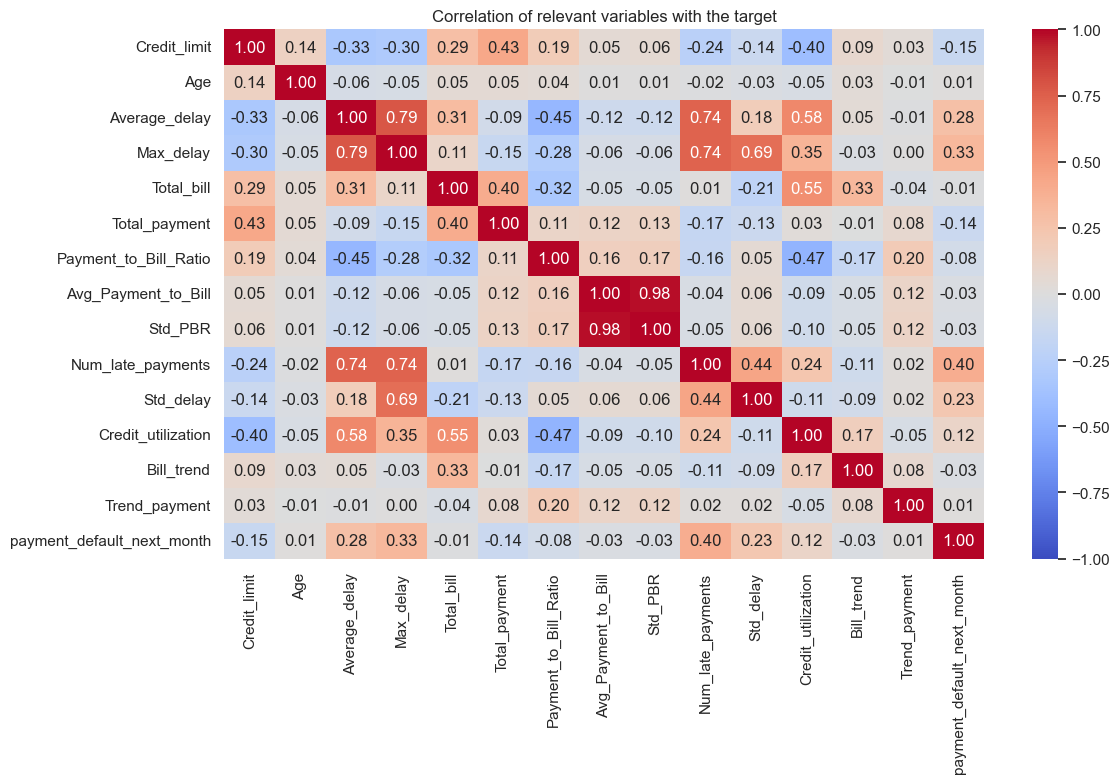


Correlations with payment_default_next_month:

payment_default_next_month    1.000000
Num_late_payments             0.398394
Max_delay                     0.330241
Average_delay                 0.281193
Std_delay                     0.234142
Credit_utilization            0.115722
Trend_payment                 0.014046
Age                           0.013647
Total_bill                   -0.014906
Bill_trend                   -0.029653
Avg_Payment_to_Bill          -0.030225
Std_PBR                      -0.031273
Payment_to_Bill_Ratio        -0.078741
Total_payment                -0.140037
Credit_limit                 -0.154572
Name: payment_default_next_month, dtype: float64


In [19]:
numeric_features = [
    'Credit_limit', 'Age',
    'Average_delay', 'Max_delay', 'Total_bill', 'Total_payment',
    'Payment_to_Bill_Ratio', 'Avg_Payment_to_Bill', 'Std_PBR',
    'Num_late_payments', 'Std_delay', 'Credit_utilization',
    'Bill_trend', 'Trend_payment'
]

corr_cols = numeric_features + ['payment_default_next_month']

plt.figure(figsize=(12,8))
sns.heatmap(
    credit_data_capped[corr_cols].corr(),
    annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f"
)
plt.title('Correlation of relevant variables with the target')
plt.tight_layout()
plt.show()

print("\nCorrelations with payment_default_next_month:\n")
print(credit_data_capped[corr_cols].corr()['payment_default_next_month'].sort_values(ascending=False))

### Correlation analysis and feature selection

**Strong correlations**

- **Num_late_payments (0.398)** and **Max_delay (0.330)**: customers with multiple late payments or a high maximum delay are much more likely to default.
- **Average_delay (0.281)** and **Std_delay (0.234)**: the average and variability of repayment delays also increase default risk, confirming the importance of historical payment behavior.

**Weak but relevant correlations**

- **Credit_utilization (0.116)**: credit utilization has a moderate but relevant relationship with default.
- **Trend_payment (0.014)** and **Age (0.014)**: these variables have limited direct influence.

**Negative correlations**

- **Credit_limit (-0.155)** and **Total_payment (-0.140)**: higher credit limits or higher total payments are associated with a slightly lower default risk.

**Summary**

Payment behavior is the strongest indicator of default risk. Traditional financial variables such as credit limit and total payment remain useful but have a more moderate effect.

For predictive modeling, delay-related variables should be prioritized. Highly correlated variables should be monitored to avoid redundant signals in the model.

## 8. Modeling Dataset Preparation

The final feature set is selected based on business relevance, correlation analysis, and interpretability.

A stratified train-test split is used to preserve the default / non-default distribution in both training and testing datasets.

In [20]:
features_to_keep = [
    'Num_late_payments', 'Max_delay', 'Average_delay',
    'Credit_utilization', 'Age', 'Total_payment', 'Total_bill',
    'Payment_to_Bill_Ratio', 'Trend_payment', 'Bill_trend', 'Avg_Payment_to_Bill'
]

if 'credit_data_capped' not in globals():
    credit_data_capped = percentile_capping(credit_data, numeric_cols)

X = credit_data_capped[features_to_keep]
y = credit_data_capped['payment_default_next_month']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape[0], "rows")
print("Test:", X_test.shape[0], "rows")
print("Train distribution:", y_train.value_counts().to_dict())
print("Test distribution:", y_test.value_counts().to_dict())

Train: 24000 rows
Test: 6000 rows
Train distribution: {0: 18691, 1: 5309}
Test distribution: {0: 4673, 1: 1327}


## 9. Baseline Model — Logistic Regression Before SMOTE

Logistic Regression is used because it is interpretable, stable, and commonly used in financial risk modeling.  
The first model is trained before resampling to establish a baseline.

In [21]:
# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
logreg_before = LogisticRegression(penalty='l2', solver='liblinear', random_state=42)
logreg_before.fit(X_train_scaled, y_train)

y_pred_before = logreg_before.predict(X_test_scaled)
y_proba_before = logreg_before.predict_proba(X_test_scaled)[:, 1]

print("RESULTS BEFORE SMOTE")
print("="*50)
print(classification_report(y_test, y_pred_before))
print("ROC AUC:", round(roc_auc_score(y_test, y_proba_before), 4))

cv_scores_before = cross_val_score(logreg_before, X_train_scaled, y_train, cv=5, scoring='roc_auc')
print("Cross-val ROC AUC (5 folds) :", round(cv_scores_before.mean(), 4), "(+/-", round(cv_scores_before.std(), 4), ")")

RESULTS BEFORE SMOTE
              precision    recall  f1-score   support

           0       0.82      0.95      0.88      4673
           1       0.62      0.28      0.38      1327

    accuracy                           0.80      6000
   macro avg       0.72      0.61      0.63      6000
weighted avg       0.78      0.80      0.77      6000

ROC AUC: 0.747
Cross-val ROC AUC (5 folds) : 0.7567 (+/- 0.0062 )


## 10. Handling Class Imbalance — SMOTE

SMOTE is applied only on the training set to avoid data leakage.

**Business interpretation:** in credit risk, improving recall is important because missing a default case may lead to financial losses.  
However, increasing recall can reduce precision and ROC AUC, which is a normal trade-off in imbalanced classification.

In [23]:
print("Before SMOTE:", y_train.value_counts().to_dict())

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("After SMOTE:", pd.Series(y_train_smote).value_counts().to_dict())

scaler_smote = StandardScaler()
X_train_smote_scaled = scaler_smote.fit_transform(X_train_smote)
X_test_smote_scaled = scaler_smote.transform(X_test)

logreg_after = LogisticRegression(penalty='l2', solver='liblinear', random_state=42)
logreg_after.fit(X_train_smote_scaled, y_train_smote)

y_pred_after = logreg_after.predict(X_test_smote_scaled)
y_proba_after = logreg_after.predict_proba(X_test_smote_scaled)[:, 1]

print("RESULTS AFTER SMOTE")
print("="*50)
print(classification_report(y_test, y_pred_after))
print("ROC AUC:", round(roc_auc_score(y_test, y_proba_after), 4))
print("Default class recall:", round(recall_score(y_test, y_pred_after, pos_label=1), 3))

# Leakage-safe cross-validation:
# SMOTE must be applied inside each CV fold, not once before cross-validation.
logreg_smote_pipeline = ImbPipeline(steps=[
    ("smote", SMOTE(random_state=42)),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(penalty='l2', solver='liblinear', random_state=42))
])

cv_scores_after = cross_val_score(logreg_smote_pipeline, X_train, y_train, cv=5, scoring='roc_auc')
print("Leakage-safe CV ROC AUC after SMOTE pipeline (5 folds):", round(cv_scores_after.mean(), 4), "(+/-", round(cv_scores_after.std(), 4), ")")


Before SMOTE: {0: 18691, 1: 5309}
After SMOTE: {0: 18691, 1: 18691}
RESULTS AFTER SMOTE
              precision    recall  f1-score   support

           0       0.88      0.77      0.82      4673
           1       0.43      0.61      0.51      1327

    accuracy                           0.73      6000
   macro avg       0.65      0.69      0.66      6000
weighted avg       0.78      0.73      0.75      6000

ROC AUC: 0.7341
Default class recall: 0.615
Leakage-safe CV ROC AUC after SMOTE pipeline (5 folds): 0.7481 (+/- 0.0048 )


## 11. Model Benchmark and Business Threshold Tuning

This section compares the interpretable Logistic Regression model with a Random Forest benchmark.  
A dedicated threshold analysis is also added because credit risk decisions rarely rely on the default 0.50 classification threshold.

**Business relevance:** in credit risk, the optimal threshold depends on the cost of false negatives, customer friction, and the institution’s risk appetite.

In [24]:
# ------------------------------------------------------------
# Model benchmark: Logistic Regression vs Random Forest
# ------------------------------------------------------------

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=30,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression before SMOTE", "Logistic Regression after SMOTE", "Random Forest benchmark"],
    "ROC_AUC": [
        roc_auc_score(y_test, y_proba_before),
        roc_auc_score(y_test, y_proba_after),
        roc_auc_score(y_test, y_proba_rf),
    ],
    "Precision_Default": [
        precision_score(y_test, y_pred_before, zero_division=0),
        precision_score(y_test, y_pred_after, zero_division=0),
        precision_score(y_test, y_pred_rf, zero_division=0),
    ],
    "Recall_Default": [
        recall_score(y_test, y_pred_before, zero_division=0),
        recall_score(y_test, y_pred_after, zero_division=0),
        recall_score(y_test, y_pred_rf, zero_division=0),
    ],
    "F1_Default": [
        f1_score(y_test, y_pred_before, zero_division=0),
        f1_score(y_test, y_pred_after, zero_division=0),
        f1_score(y_test, y_pred_rf, zero_division=0),
    ],
})

model_comparison.iloc[:, 1:] = model_comparison.iloc[:, 1:].round(4)
display(model_comparison)

print("Random Forest classification report:")
print(classification_report(y_test, y_pred_rf))


,Model,ROC_AUC,Precision_Default,Recall_Default,F1_Default
0,Logistic Regression before SMOTE,0.7470,0.6168,0.2766,0.3819
1,Logistic Regression after SMOTE,0.7341,0.4288,0.6149,0.5053
2,Random Forest benchmark,0.7682,0.4427,0.6315,0.5205


Random Forest classification report:
              precision    recall  f1-score   support

           0       0.88      0.77      0.82      4673
           1       0.44      0.63      0.52      1327

    accuracy                           0.74      6000
   macro avg       0.66      0.70      0.67      6000
weighted avg       0.78      0.74      0.76      6000



## Model Interpretation

Logistic Regression before SMOTE:
- High precision (~0.62) but very low recall (~0.28)
- The model misses a large portion of defaulting clients
- This leads to an underestimation of credit risk and is not suitable for production

Logistic Regression after SMOTE:
- Recall significantly improves (~0.61), allowing better detection of high-risk customers
- Precision decreases (~0.43), meaning more low-risk clients are incorrectly flagged
- This reflects a typical trade-off between risk detection and operational efficiency

Random Forest:
- Provides the best overall performance (ROC AUC ~0.77, F1 ~0.52)
- Maintains strong recall (~0.63)
- Offers a better balance between predictive accuracy and risk detection

Business Conclusion:
- In credit risk, recall is critical because missing a defaulter leads to financial losses
- SMOTE improves risk coverage and strengthens the model’s ability to detect risky clients
- Random Forest delivers the best predictive performance
- Logistic Regression remains preferred for its interpretability and alignment with regulatory requirements

Final approach:
- Logistic Regression is used for scoring and explainability
- Random Forest is used as a benchmark to validate model performance

In [25]:
# ------------------------------------------------------------
# Threshold tuning for business decision-making
# ------------------------------------------------------------

thresholds = np.arange(0.10, 0.91, 0.05)
threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_proba_after >= threshold).astype(int)
    threshold_results.append({
        "Threshold": threshold,
        "Precision_Default": precision_score(y_test, y_pred_threshold, zero_division=0),
        "Recall_Default": recall_score(y_test, y_pred_threshold, zero_division=0),
        "F1_Default": f1_score(y_test, y_pred_threshold, zero_division=0),
        "Predicted_Default_Rate": y_pred_threshold.mean(),
    })

threshold_df = pd.DataFrame(threshold_results).round(4)
display(threshold_df)

# Select the best threshold by F1-score as a neutral statistical benchmark.
# In a real bank or fintech environment, this threshold should be adjusted using the cost of false negatives vs false positives.
best_threshold = threshold_df.loc[threshold_df["F1_Default"].idxmax(), "Threshold"]
y_pred_best_threshold = (y_proba_after >= best_threshold).astype(int)

print(f"Selected threshold based on best F1-score: {best_threshold:.2f}")
print(classification_report(y_test, y_pred_best_threshold))
print("Confusion matrix at selected threshold:")
print(confusion_matrix(y_test, y_pred_best_threshold))


,Threshold,Precision_Default,Recall_Default,F1_Default,Predicted_Default_Rate
0,0.10,0.2238,0.9977,0.3655,0.9862
1,0.15,0.2272,0.9955,0.3700,0.9690
2,0.20,0.2326,0.9849,0.3764,0.9363
3,0.25,0.2414,0.9586,0.3857,0.8782
4,0.30,0.2562,0.8907,0.3980,0.7688
5,0.35,0.2971,0.7988,0.4331,0.5947
6,0.40,0.3625,0.6933,0.4761,0.4230
7,0.45,0.4161,0.6315,0.5016,0.3357
8,0.50,0.4288,0.6149,0.5053,0.3172
9,0.55,0.4343,0.6074,0.5064,0.3093


Selected threshold based on best F1-score: 0.60
              precision    recall  f1-score   support

           0       0.87      0.79      0.83      4673
           1       0.45      0.59      0.51      1327

    accuracy                           0.75      6000
   macro avg       0.66      0.69      0.67      6000
weighted avg       0.78      0.75      0.76      6000

Confusion matrix at selected threshold:
[[3707  966]
 [ 549  778]]


## Threshold Optimization — Business Interpretation

The threshold analysis highlights the trade-off between precision and recall as the decision threshold increases.

At lower thresholds (e.g. 0.30–0.50):
- Recall is high → the model captures most defaulting customers  
- Precision is lower → more non-risky customers are flagged  
- This leads to broader risk coverage but higher operational cost  

At higher thresholds (e.g. 0.70–0.90):
- Precision increases → flagged customers are more likely to default  
- Recall drops significantly → many risky clients are missed  
- This reduces operational load but increases financial risk  

Selected threshold: 0.60 (based on best F1-score)

At this threshold:
- Precision (~0.45) indicates moderate targeting accuracy  
- Recall (~0.59) ensures a good level of risk detection  
- The model maintains a balanced trade-off between detection and efficiency  

Confusion Matrix Interpretation:
- True Negatives (3707): correctly identified low-risk customers  
- False Positives (966): safe customers incorrectly flagged → operational cost  
- False Negatives (549): risky customers missed → direct financial loss  
- True Positives (778): correctly identified defaulters  

Business Perspective:
- False negatives are the most critical error in credit risk  
- The selected threshold (0.60) reduces missed defaulters while keeping false positives manageable  

Final Recommendation:
- Use threshold = 0.60 for balanced decision-making  
- Adjust threshold dynamically depending on risk appetite:
  - Lower threshold → aggressive risk detection  
  - Higher threshold → stricter approval policy  

This approach aligns the model with real-world credit risk strategies,
where decision thresholds are calibrated based on business objectives and risk tolerance.

## 12. ROC Curve — Before vs After SMOTE

The ROC curve compares the baseline model and the SMOTE-based model.

The objective is not only to maximize global statistical performance, but to evaluate whether the model better detects risky customers.

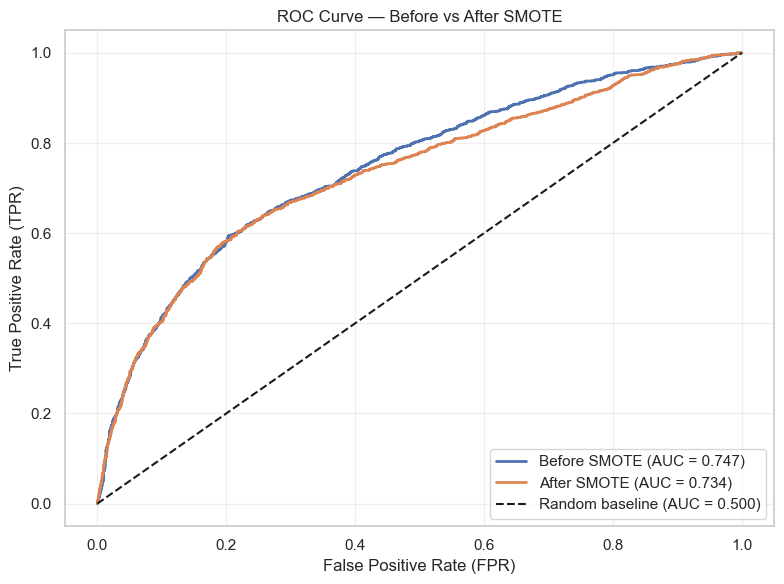

In [26]:
if 'y_proba_before' not in globals():
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    logreg_before = LogisticRegression(penalty='l2', solver='liblinear', random_state=42)
    logreg_before.fit(X_train_scaled, y_train)
    y_proba_before = logreg_before.predict_proba(X_test_scaled)[:, 1]

if 'y_proba_after' not in globals():
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
    scaler_smote = StandardScaler()
    X_train_smote_scaled = scaler_smote.fit_transform(X_train_smote)
    X_test_smote_scaled = scaler_smote.transform(X_test)
    logreg_after = LogisticRegression(penalty='l2', solver='liblinear', random_state=42)
    logreg_after.fit(X_train_smote_scaled, y_train_smote)
    y_proba_after = logreg_after.predict_proba(X_test_smote_scaled)[:, 1]

fpr_before, tpr_before, _ = roc_curve(y_test, y_proba_before)
fpr_after, tpr_after, _ = roc_curve(y_test, y_proba_after)

plt.figure(figsize=(8, 6))
plt.plot(fpr_before, tpr_before, label=f"Before SMOTE (AUC = {roc_auc_score(y_test, y_proba_before):.3f})", linewidth=2)
plt.plot(fpr_after, tpr_after, label=f"After SMOTE (AUC = {roc_auc_score(y_test, y_proba_after):.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random baseline (AUC = 0.500)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve — Before vs After SMOTE')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## ROC Curve — Business Interpretation

The ROC curve compares the model’s ability to distinguish between defaulting and non-defaulting clients before and after applying SMOTE.

Key observations:
- Both models perform significantly better than a random classifier (AUC = 0.50)
- The baseline model (before SMOTE) achieves a slightly higher AUC (~0.75)
- After SMOTE, AUC slightly decreases (~0.73)

Interpretation:
- The slight drop in AUC after SMOTE indicates a minor loss in overall ranking performance
- However, this does not necessarily mean the model is worse in a business context

Business perspective:
- AUC measures global discrimination ability, but does not capture the model’s effectiveness in detecting high-risk customers
- After SMOTE, the model improves recall, meaning more defaulting clients are correctly identified
- This is critical in credit risk, where missing a defaulter leads to direct financial loss

Trade-off:
- Before SMOTE → better global performance (AUC), but weaker risk detection
- After SMOTE → slightly lower AUC, but stronger detection of risky clients

Conclusion:
- The SMOTE model is more aligned with credit risk objectives
- In practice, improving detection of defaulters is more valuable than maximizing AUC
- Model evaluation should not rely solely on AUC
- Business-oriented metrics such as recall and expected loss are more relevant for decision-making

## 13. Model Coefficients and Risk Drivers

Logistic Regression coefficients help interpret which variables increase or decrease default risk.

**Business relevance:** interpretability is essential in finance because risk decisions must be explainable.

In [27]:
if 'logreg_after' not in globals():
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

    scaler_smote = StandardScaler()
    X_train_smote_scaled = scaler_smote.fit_transform(X_train_smote)
    X_test_smote_scaled = scaler_smote.transform(X_test)

    logreg_after = LogisticRegression(penalty='l2', solver='liblinear', random_state=42)
    logreg_after.fit(X_train_smote_scaled, y_train_smote)

df_coeffs = pd.DataFrame({
    'Variable': features_to_keep,
    'Coefficient': logreg_after.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("Feature weights / scoring coefficients (after SMOTE):")
print(df_coeffs.to_string(index=False))

Feature weights / scoring coefficients (after SMOTE):
             Variable  Coefficient
            Max_delay     0.601474
    Num_late_payments     0.534368
        Total_payment    -0.366920
        Average_delay    -0.264601
   Credit_utilization     0.150622
                  Age     0.079306
        Trend_payment     0.061618
Payment_to_Bill_Ratio     0.049984
           Total_bill     0.033591
           Bill_trend    -0.003663
  Avg_Payment_to_Bill    -0.003525


### Interpretation of model coefficients and risk scoring

**Most influential default risk drivers**

- **Num_late_payments**: the number of late payment months is the strongest driver and significantly increases default risk.
- **Max_delay**: the maximum observed delay also increases default risk.
- **Average_delay**: this coefficient should be interpreted carefully because it is correlated with other delay-related variables.

**Important financial variables**

- **Total_payment**: higher total payments generally reduce default risk.
- **Credit_utilization**: higher credit utilization increases default risk.
- **Payment_to_Bill_Ratio** and **Avg_Payment_to_Bill**: these variables have a weaker but consistent effect; higher repayment ratios generally indicate better repayment capacity.

**Other variables**

- **Age**, **Total_bill**, **Bill_trend** and **Trend_payment** have a more moderate influence on the final score.

**Business interpretation**

The scoring system is mainly driven by repayment delays and credit behavior. Financial variables help refine the customer risk assessment and support credit monitoring decisions.

## 14. Credit Risk Scoring System

Predicted probabilities are converted into a 0–100 risk score.  
This makes the model output easier to use in business workflows such as credit approval, portfolio monitoring, and Power BI dashboards.

In [28]:
if 'y_proba_after' not in globals():
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

    scaler_smote = StandardScaler()
    X_train_smote_scaled = scaler_smote.fit_transform(X_train_smote)
    X_test_smote_scaled = scaler_smote.transform(X_test)

    logreg_after = LogisticRegression(penalty='l2', solver='liblinear', random_state=42)
    logreg_after.fit(X_train_smote_scaled, y_train_smote)

    y_proba_after = logreg_after.predict_proba(X_test_smote_scaled)[:, 1]

if 'best_threshold' not in globals():
    best_threshold = 0.50

score_0_100 = np.round(y_proba_after * 100).astype(int)

df_results = X_test.copy()
df_results['Customer_id'] = credit_data_capped.loc[X_test.index, 'Customer_id'].values
df_results['Credit_limit'] = credit_data_capped.loc[X_test.index, 'Credit_limit'].values
df_results['Actual_Default'] = y_test.values
df_results['Pred_Prob'] = y_proba_after
df_results['Pred_Default_Threshold'] = (y_proba_after >= best_threshold).astype(int)
df_results['Decision_Threshold'] = best_threshold
df_results['Score_0_100'] = score_0_100

def risk_category(score):
    if score <= 33:
        return 'Low'
    elif score <= 66:
        return 'Medium'
    else:
        return 'High'

df_results['Risk_Level'] = df_results['Score_0_100'].apply(risk_category)

df_results[['Customer_id', 'Actual_Default', 'Pred_Prob', 'Pred_Default_Threshold', 'Decision_Threshold', 'Score_0_100', 'Risk_Level']].head(10)


,Customer_id,Actual_Default,Pred_Prob,Pred_Default_Threshold,Decision_Threshold,Score_0_100,Risk_Level
6907,6908,0,0.322524,0,0.6,32,Low
24575,24576,0,0.290424,0,0.6,29,Low
26766,26767,0,0.406589,0,0.6,41,Medium
2156,2157,1,0.265098,0,0.6,27,Low
3179,3180,0,0.143817,0,0.6,14,Low
29382,29383,0,0.419710,0,0.6,42,Medium
24454,24455,0,0.349765,0,0.6,35,Medium
23886,23887,0,0.237440,0,0.6,24,Low
5504,5505,0,0.271446,0,0.6,27,Low
29720,29721,0,0.355033,0,0.6,36,Medium


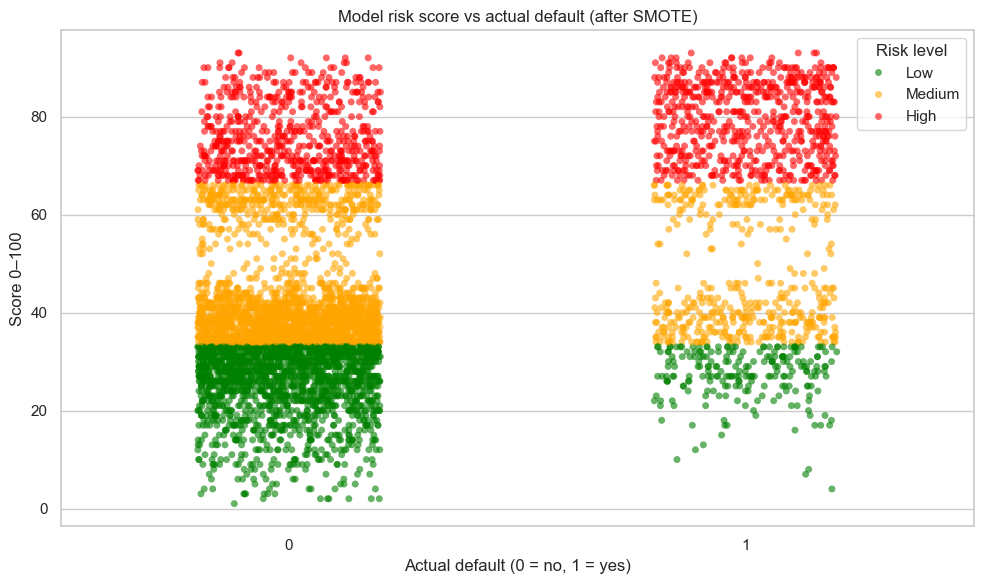

In [29]:
plt.figure(figsize=(10, 6))
sns.stripplot(
    x='Actual_Default',
    y='Score_0_100',
    data=df_results,
    hue='Risk_Level',
    jitter=0.2,
    palette={'Low': 'green', 'Medium': 'orange', 'High': 'red'},
    alpha=0.6
)
plt.xlabel("Actual default (0 = no, 1 = yes)")
plt.ylabel("Score 0–100")
plt.title("Model risk score vs actual default (after SMOTE)")
plt.legend(title='Risk level')
plt.tight_layout()
plt.show()

## Final Risk Scoring — Business Interpretation

The scoring model shows a clear separation between non-defaulting (0) and defaulting clients (1).

Key observations:
- Defaulting customers are mostly concentrated in the high-risk zone (scores > 66)
- Non-defaulting customers are largely in the low and medium risk segments
- Some overlap remains, reflecting real-world uncertainty in credit risk

Business insight:
- The model effectively prioritizes high-risk customers
- High scores are strongly associated with default probability
- The segmentation enables actionable decision-making

Operational impact:
- High-risk clients → stricter approval or rejection
- Medium-risk clients → additional checks or adjusted conditions
- Low-risk clients → fast approval process

Final takeaway:
- The scoring system is aligned with real credit risk practices
- It provides a clear, usable framework for risk-based decision-making

## 15. Final Export for Business Use

The final dataset contains customer-level risk scores and key engineered indicators.  
This output can be used in Power BI or SQL to build dashboards, segment customers, and support credit risk monitoring.

In [30]:
cols_final = [
    'Customer_id', 'Age', 'Credit_limit', 'Credit_utilization', 'Actual_Default',
    'Num_late_payments', 'Max_delay', 'Average_delay',
    'Total_payment', 'Total_bill', 'Bill_trend', 'Trend_payment',
    'Payment_to_Bill_Ratio', 'Pred_Prob', 'Pred_Default_Threshold',
    'Decision_Threshold', 'Score_0_100', 'Risk_Level'
]

df_final_clean = df_results[cols_final].copy()

df_final_clean['Average_delay'] = df_final_clean['Average_delay'].round(1)
df_final_clean['Trend_payment'] = df_final_clean['Trend_payment'].round(1)
df_final_clean['Payment_to_Bill_Ratio'] = df_final_clean['Payment_to_Bill_Ratio'].round(2)
df_final_clean['Pred_Prob'] = df_final_clean['Pred_Prob'].round(3)
df_final_clean['Decision_Threshold'] = df_final_clean['Decision_Threshold'].round(2)
df_final_clean['Total_payment'] = df_final_clean['Total_payment'].round(0).astype(int)
df_final_clean['Total_bill'] = df_final_clean['Total_bill'].round(0).astype(int)
df_final_clean['Bill_trend'] = df_final_clean['Bill_trend'].round(0).astype(int)

df_final_clean.head(10)


,Customer_id,Age,Credit_limit,Credit_utilization,Actual_Default,Num_late_payments,Max_delay,Average_delay,Total_payment,Total_bill,Bill_trend,Trend_payment,Payment_to_Bill_Ratio,Pred_Prob,Pred_Default_Threshold,Decision_Threshold,Score_0_100,Risk_Level
6907,6908,46.0,50000.0,0.726680,0,0,0.0,-0.7,36457,36334,-1224,-23219.0,1.00,0.323,0,0.6,32,Low
24575,24576,31.0,150000.0,0.177960,0,0,-1.0,-1.5,41694,26694,3306,30000.0,1.56,0.290,0,0.6,29,Low
26766,26767,25.0,50000.0,5.931180,0,0,0.0,0.0,11682,296559,-2637,238.0,0.04,0.407,0,0.6,41,Medium
2156,2157,25.0,290000.0,5.612472,1,0,0.0,0.0,81677,1627617,74898,8333.0,0.05,0.265,0,0.6,27,Low
3179,3180,27.0,500000.0,0.129814,0,0,-2.0,-2.0,78874,64907,1354,15321.0,1.22,0.144,0,0.6,14,Low
29382,29383,29.0,200000.0,5.897660,0,2,2.0,0.5,145040,1179532,-4705,0.0,0.12,0.420,0,0.6,42,Medium
24454,24455,31.0,210000.0,3.155581,0,0,0.0,0.0,21400,662672,109345,-2000.0,0.03,0.350,0,0.6,35,Medium
23886,23887,35.0,260000.0,1.073596,0,0,0.0,0.0,60399,279135,-26794,0.0,0.22,0.237,0,0.6,24,Low
5504,5505,42.0,450000.0,0.196447,0,0,-1.0,-1.0,30264,88401,72517,14380.0,0.34,0.271,0,0.6,27,Low
29720,29721,39.0,150000.0,0.894427,0,0,0.0,0.0,8900,134164,28818,200.0,0.07,0.355,0,0.6,36,Medium


In [31]:
df_final_clean = df_final_clean.reset_index(drop=True)

In [32]:
# ==============================
# FINAL EXPORT FOR GITHUB
# ==============================

os.makedirs("outputs", exist_ok=True)

required_columns = ["Pred_Prob", "Score_0_100", "Risk_Level"]
missing_columns = [col for col in required_columns if col not in df_final_clean.columns]

if missing_columns:
    raise ValueError(f"Missing required final columns: {missing_columns}")

output_path = Path("outputs/credit_risk_scoring_results.csv")
df_final_clean.to_csv(output_path, index=False)

print(f"Final dataset exported successfully: {output_path}")
print(f"Shape of dataset: {df_final_clean.shape}")
print("Columns exported:")
print(list(df_final_clean.columns))


Final dataset exported successfully: outputs\credit_risk_scoring_results.csv
Shape of dataset: (6000, 18)
Columns exported:
['Customer_id', 'Age', 'Credit_limit', 'Credit_utilization', 'Actual_Default', 'Num_late_payments', 'Max_delay', 'Average_delay', 'Total_payment', 'Total_bill', 'Bill_trend', 'Trend_payment', 'Payment_to_Bill_Ratio', 'Pred_Prob', 'Pred_Default_Threshold', 'Decision_Threshold', 'Score_0_100', 'Risk_Level']


## Business Conclusion

This project delivers an interpretable credit risk scoring framework that combines financial risk expertise, feature engineering, machine learning and decision-oriented scoring.

**Key takeaways:**
- Repayment delays are the strongest indicators of default risk.
- Logistic Regression remains the preferred final model for interpretability and explainability in a financial risk context.
- SMOTE improves the model’s ability to detect default cases, but the recall/precision trade-off must be monitored.
- A leakage-safe SMOTE pipeline is used for cross-validation, which makes the evaluation more credible for a professional portfolio.
- A Random Forest benchmark is included to compare performance against a stronger non-linear model.
- Threshold tuning translates model probabilities into business decisions aligned with risk appetite.
- The final scoring output is ready for Power BI, SQL analysis, portfolio segmentation and risk monitoring.

**Limitations:**
- The dataset does not include income, employment status, macroeconomic variables or recent behavioral data.
- Logistic Regression assumes mostly linear relationships between features and default probability.
- Some engineered variables are correlated, so coefficients must be interpreted with caution.
- The threshold selected here is statistical; in production, it should be calibrated using business costs and regulatory constraints.

**Next improvements:**
- Test XGBoost or LightGBM with careful leakage controls.
- Add cost-sensitive threshold optimization.
- Monitor score stability and model drift over time.
- Add expected loss estimation using PD × EAD × LGD.
